#Day 1: Read and Plot Sensor Data
**Author:** Mridhul Sudhagona
**Date:** 2026-05-05

Goal:
Learn how to load simple vehicle sensor data, filter it, and plot vehicle speed over time using pandas and matplotlib. this mirros how ADAS engineers analyze logs from vehicles , simluators, radars piplelines, cameras, and CAN bus messages.

## Concept (in my own words)
Vehicle sensors generate a continuous stream of measurements over time:
speed, acceleration, steering, brake, GPS, etc. Each measurement has
a timestamp. To analyze them, I:

1. Load the log into a table (rows = time samples, columns = sensors).
2. Clean and filter (drop bad rows, keep relevant time windows).
3. Plot trends over time to spot events — sudden braking, sharp turns.

The same workflow applies whether the data comes from a real car,
a CARLA simulator, a radar log, or a CAN bus dump.

In [3]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 4) 

In [4]:
# We'll simulate 60 seconds of driving sampled at 10 Hz (10 readings per second).
# That's 600 rows. Sample rate matters — real ADAS sensors run at 10 to 100+ Hz.

np.random.seed(42)  # makes the random data the same every run (reproducibility)

duration_sec = 60
sample_rate_hz = 10
n_samples = duration_sec * sample_rate_hz   # 600

# Time axis: 0.0, 0.1, 0.2, ... up to 59.9 seconds
timestamps = np.arange(0, duration_sec, 1 / sample_rate_hz)

# Speed: starts at 0, accelerates to ~25 m/s (~56 mph), holds, then decelerates
# Use a smooth curve plus tiny random noise to mimic sensor jitter
base_speed = 25 * np.sin(timestamps / 60 * np.pi)  # smooth half-sine over 60s
speed = base_speed + np.random.normal(0, 0.3, n_samples)  # add noise
speed = np.clip(speed, 0, None)                            # speed can't be negative

# Acceleration: derivative of speed, approximately
# np.diff gives differences between consecutive elements (length n_samples - 1)
# We pad the front with a 0 so it stays length n_samples
acceleration = np.concatenate(([0], np.diff(speed))) * sample_rate_hz

# Steering angle in degrees: gentle wandering plus occasional turns
steering = 5 * np.sin(timestamps / 5) + np.random.normal(0, 0.5, n_samples)

# Brake pressure 0 to 1: bursts when decelerating
brake = np.where(acceleration < -0.5, 0.6 + np.random.uniform(0, 0.3, n_samples), 0)

# Build a pandas DataFrame — the table
df = pd.DataFrame({
    'timestamp_s'      : timestamps,
    'speed_mps'        : speed,
    'accel_mps2'       : acceleration,
    'steering_deg'     : steering,
    'brake_pressure'   : brake,
})

# Save it to CSV so the next cell can read it back (mimics a real log file)
df.to_csv('vehicle_log.csv', index=False)

print(f"Generated {len(df)} rows.")
df.head()   # show first 5 rows

Generated 600 rows.


,timestamp_s,speed_mps,accel_mps2,steering_deg,brake_pressure
0,0.0,0.149014,0.000000,0.378494,0.000000
1,0.1,0.089420,-0.595944,-0.361089,0.789945
2,0.2,0.456101,3.666814,0.634750,0.000000
3,0.3,0.849592,3.934907,0.977639,0.000000
4,0.4,0.453314,-3.962774,0.606291,0.845757


In [11]:
#pretned we didn't gernertae it ourselevs - read it back from disk like real log 
log = pd.read_csv('vehicle_log.csv') 

#Quick sanity check
print("Shape (rows, columns):", log.shape) 
print("\nColumn types:")
print(log.dtypes)
print("\nQuick statistical summary:")
log.describe()

Shape (rows, columns): (600, 5)

Column types:
timestamp_s       float64
speed_mps         float64
accel_mps2        float64
steering_deg      float64
brake_pressure    float64
dtype: object

Quick statistical summary:


,timestamp_s,speed_mps,accel_mps2,steering_deg,brake_pressure
count,600.000000,600.000000,600.000000,600.000000,600.000000
mean,29.950000,15.911402,0.001585,0.112436,0.330266
std,17.334936,7.726361,4.245601,3.609153,0.375757
min,0.000000,0.089420,-12.991771,-6.145592,0.000000
25%,14.975000,9.521747,-3.113607,-3.604269,0.000000
50%,29.950000,17.665030,0.152652,0.233782,0.000000
75%,44.925000,23.150857,2.926841,3.653709,0.732069
max,59.900000,25.552231,11.535604,5.887951,0.899504


In [12]:
# FILTER 1: rows where vehicle is moving (speed above 1 m/s)
moving = log[log['speed_mps'] > 1.0]
print(f"Total rows:              {len(log)}")
print(f"Rows while moving:       {len(moving)}")

# FILTER 2: hard braking events (brake pressure above 0.5)
hard_braking = log[log['brake_pressure'] > 0.5]
print(f"Hard braking rows:       {len(hard_braking)}")

# FILTER 3: sharp turns while moving
sharp_turns = log[(log['speed_mps'] > 5.0) & (log['steering_deg'].abs() > 5.0)]
print(f"Sharp turn rows:         {len(sharp_turns)}")

# Now show the hard braking rows
hard_braking.head()

Total rows:              600
Rows while moving:       588
Hard braking rows:       265
Sharp turn rows:         78


,timestamp_s,speed_mps,accel_mps2,steering_deg,brake_pressure
1,0.1,0.089420,-0.595944,-0.361089,0.789945
4,0.4,0.453314,-3.962774,0.606291,0.845757
7,0.7,1.146323,-1.127097,0.075388,0.663613
8,0.8,0.906049,-2.402741,-0.092769,0.783294
10,1.0,1.169374,-1.710557,1.320529,0.851958


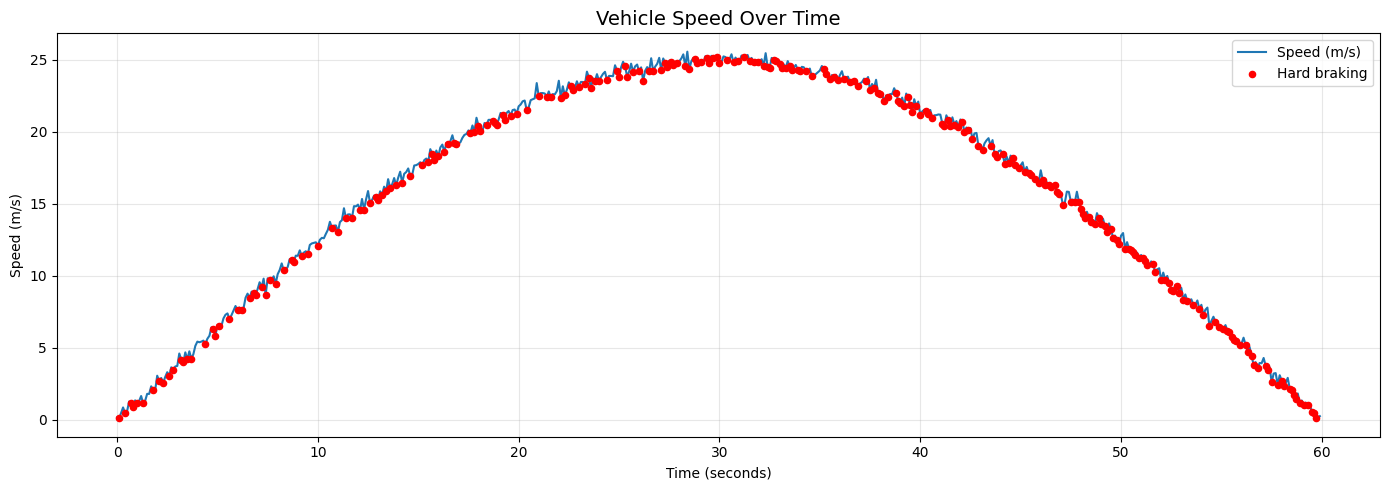

In [13]:
plt.figure(figsize=(14, 5))

# Main line: speed vs time
plt.plot(log['timestamp_s'], log['speed_mps'], label='Speed (m/s)', linewidth=1.5)

# Highlight hard-braking samples as red dots
plt.scatter(hard_braking['timestamp_s'], hard_braking['speed_mps'],
            color='red', s=20, label='Hard braking', zorder=5)

plt.title('Vehicle Speed Over Time', fontsize=14)
plt.xlabel('Time (seconds)')
plt.ylabel('Speed (m/s)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Result
- Speed follows a smooth bell shape, peaking around t = 30s.
- Hard-braking samples (red) cluster on the descending side as expected — when decelerating, brake pressure goes up.
- About XX% of the trip was spent in motion (above 1 m/s).


---

# Part 2 — Jira Ticket: NumPy Multi-Dimensional Sensor Operations

## Goal
Manipulate multi-dimensional sensor arrays using NumPy:
- Slicing, masking, and broadcasting on a simulated radar point cloud
- Rolling mean and standard deviation on a 1D acceleration signal
- Vectorized operations vs Python for-loops with timing comparison

## Concept (in my own words)
NumPy stores numbers in tight blocks of memory and runs math in compiled C
under the hood. That's why a vectorized operation on a million-element array
can be 100x faster than a Python for-loop doing the same thing. ADAS pipelines
deal with point clouds (LiDAR/radar), images, and time-series — all of which
are multi-dimensional arrays. NumPy is the foundation everything sits on.

In [15]:
# CREATE the radar point cloud first
# A radar sensor outputs a list of detected points in 3D space
# Each point has: x position, y position, z position, intensity

np.random.seed(7)
n_points = 1000

radar = np.column_stack([
    np.random.uniform(-50, 50, n_points),   # x: left/right in meters
    np.random.uniform(0, 100, n_points),    # y: forward distance in meters  
    np.random.uniform(-2, 4, n_points),     # z: height in meters
    np.random.uniform(0, 1, n_points),      # intensity: how strong the reflection
])

print("Radar array shape:", radar.shape)
print("First 3 points:\n", radar[:3])

Radar array shape: (1000, 4)
First 3 points:
 [[-42.36917106   8.37858701   1.59371369   0.69002066]
 [ 27.99187922  52.61529088   2.38732269   0.67296299]
 [ -6.15907686  38.17346083   2.46225947   0.89724969]]


In [ ]:
# Slice = grab a contiguous block. No copy in most cases — just a view into the same memory.

# All rows, only the first 3 columns (x, y, z)
xyz = radar[:, :3]
print("xyz shape:", xyz.shape)

# First 5 points only
first_5 = radar[:5]
print("First 5 rows:\n", first_5)

# Just the y-column (a 1D array of all 1000 y-values)
y_only = radar[:, 1]
print("y_only shape:", y_only.shape)